# 79 Log-compression contrast sweep for the FFT-magnitude heat map

Load one sample from a dataset (set with the `DATASET` env var, default `gastronorm`)
and plot the FFT magnitude of all 100 lasers (y-axis) vs frequency (x-axis) as a heat
map, under several logarithmic compressions `log(1 + |FFT| / k)`. The goal: find which
compression strength `k` gives the heat map the most visual contrast (differentiation
between pixels). (See section 2 for why we sweep `k` rather than the log base itself.)

We score each transform with two complementary, well-established contrast metrics
(defined in section 2) and pick the `k` that maximizes them.

# 0 Imports & config

In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parent
DATASET = os.environ.get("DATASET", "gastronorm")
print(f"DATASET = {DATASET}  (override with the DATASET env var)")

# dataset -> samples dir (same boxes as notebook 77)
DATASET_DIRS = {
    "gastronorm": REPO / "experiments/31_07_2026_gastronorm_exp1/samples",
    "plastic":    REPO / "experiments/31_08_2026_green_plastic_two_laser_faces/samples",
    "wood":       REPO / "experiments/2026_09_06_wood_box/samples",
    "cardboard":  REPO / "experiments/2026_09_07_cardboard_box/samples",
    "shoebox":    REPO / "experiments/2026_09_08_shoebox/samples",
}
SAMPLES_DIR = DATASET_DIRS[DATASET]
assert SAMPLES_DIR.is_dir(), f"missing {DATASET}: {SAMPLES_DIR}"

DATASET = gastronorm  (override with the DATASET env var)


# 1 Load one sample

Each sample's FFT is stored as `vibration/04_fft.npz` (gastronorm) or
`vibration/04_ffts.npz` (other boxes), a complex array of shape `(1, L, F, C)` — 1
capture, `L` lasers (100), `F` frequency bins, `C` = 2 channels (x/y). We take the
magnitude, average over the x/y channel, and pick the first non-empty sample we find.

In [2]:
FFT_NAMES = ["vibration/04_fft.npz", "vibration/04_ffts.npz"]


def find_fft_path(samples_dir: Path) -> Path:
    for sample_dir in sorted(p for p in samples_dir.glob("*") if p.is_dir()):
        for name in FFT_NAMES:
            p = sample_dir / name
            if p.exists():
                return p
    raise FileNotFoundError(f"no FFT file found under {samples_dir}")


fft_path = find_fft_path(SAMPLES_DIR)
print(f"sample: {fft_path.relative_to(REPO)}")

with np.load(fft_path) as z:
    fft, freqs = z["fft"], z["freqs"]

# (1, L, F, C) complex -> magnitude, averaged over x/y channel -> (L, F)
mag = np.abs(fft[0]).mean(axis=-1)
print(f"mag shape (lasers, freq bins) = {mag.shape}")
print(f"freq range = {freqs[0]:.1f}-{freqs[-1]:.1f} Hz")
print(f"mag range = [{mag.min():.4g}, {mag.max():.4g}], mean={mag.mean():.4g}")

sample: experiments/31_07_2026_gastronorm_exp1/samples/000010/vibration/04_fft.npz
mag shape (lasers, freq bins) = (100, 1235)
freq range = 50.8-1000.0 Hz
mag range = [0.0025, 26.01], mean=0.7612


# 2 Measuring contrast

**Note on parameterization.** `log_b(1 + x) = ln(1 + x) / ln(b)` &mdash; changing the
base only multiplies every pixel by the constant `1/ln(b)`. After min-max normalizing
to `[0, 1]` that constant cancels out completely, so a pure base sweep is a no-op: all
bases produce the *identical* normalized image. The parameter that actually reshapes
the image is a **compression scale `k`** inside the log:
`T_k(x) = log(1 + x / k)`. Small `k` compresses hard (pulls the whole dynamic range
into a similar few decades, boosting quiet regions); large `k` approaches the
identity/linear transform. We sweep `k` (equivalent to sweeping the *effective* base
against a fixed input scale) and report contrast as a function of `k`.

We apply `T_k(x) = log(1 + x/k)`, min-max normalize the result to `[0, 1]`, and score
the normalized image `I` with two standard, complementary contrast measures:

1. **RMS contrast** &mdash; the standard deviation of pixel intensities,
   `C_rms = std(I)`. This is the textbook mathematical definition of image contrast
   (Peli, 1990): it directly measures how spread out the pixel values are around
   their mean, i.e. how much pixels *differ from each other* on average. Higher =
   more differentiation. It's sensitive to the *whole distribution*, not just extremes.

2. **Shannon entropy of the pixel histogram** &mdash; `H = -sum(p_k * log2(p_k))` over
   256 intensity bins. RMS contrast can be fooled by a bimodal image (most pixels
   identical, a few extreme outliers) that has high variance but low *usable* dynamic
   range. Entropy instead measures how *evenly the pixel values populate the available
   range* — it's maximized when intensities are spread uniformly across bins, which is
   exactly what you want for an image to show fine differentiation everywhere (the
   same principle behind histogram equalization). Higher = more bits of information
   per pixel = more differentiation.

We report both, plus their product-of-ranks, since a good compression scale should
score well on both: high spread (RMS) *and* that spread well-distributed across the
range (entropy), not concentrated in a couple of histogram bins.

In [3]:
def normalize01(x: np.ndarray) -> np.ndarray:
    """Min-max normalize to [0, 1]."""
    lo, hi = x.min(), x.max()
    return (x - lo) / (hi - lo) if hi > lo else np.zeros_like(x)


def log_transform(mag: np.ndarray, k: float) -> np.ndarray:
    """log(1 + mag/k), then min-max normalized to [0, 1]. Small k compresses harder."""
    scaled = np.log1p(mag / k)
    return normalize01(scaled)


def rms_contrast(img01: np.ndarray) -> float:
    """Standard deviation of pixel intensities (Peli's RMS contrast)."""
    return float(img01.std())


def shannon_entropy(img01: np.ndarray, n_bins: int = 256) -> float:
    """Shannon entropy (bits) of the pixel-intensity histogram."""
    hist, _ = np.histogram(img01, bins=n_bins, range=(0.0, 1.0))
    p = hist / hist.sum()
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())

# 3 Sweep compression scale and score contrast

We sweep `k` in `log(1 + x/k)` in log-space, from well below the magnitude's min
(≈ raw magnitude, no compression benefit) to well above its max (heavy compression,
approaching a linear ramp near 0 before saturating).

In [4]:
import pandas as pd

# log-spaced compression scales k, from well below mag.min() to well above mag.max()
K_VALUES = np.logspace(np.log10(mag.max() * 1e-4), np.log10(mag.max() * 10), 40)

rows = []
for k in K_VALUES:
    img = log_transform(mag, k)
    rows.append(dict(
        k=k,
        rms_contrast=rms_contrast(img),
        entropy_bits=shannon_entropy(img),
    ))

scores = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)
scores["rms_rank"] = scores["rms_contrast"].rank(ascending=False)
scores["entropy_rank"] = scores["entropy_bits"].rank(ascending=False)
scores["combined_rank_score"] = scores["rms_rank"] * scores["entropy_rank"]  # lower = better on both
scores = scores.sort_values("combined_rank_score").reset_index(drop=True)

best = scores.iloc[0]
print(f"best compression scale: k={best['k']:.4g}  "
      f"(rms={best['rms_contrast']:.4f}, entropy={best['entropy_bits']:.4f} bits)")
scores.head(10)

best compression scale: k=0.02054  (rms=0.1901, entropy=7.4986 bits)


,k,rms_contrast,entropy_bits,rms_rank,entropy_rank,combined_rank_score
0,0.020537,0.190121,7.498568,6.0,1.0,6.0
1,0.049791,0.193333,7.443187,1.0,9.0,9.0
2,0.027589,0.191910,7.490760,4.0,3.0,12.0
3,0.037063,0.193031,7.472918,2.0,6.0,12.0
4,0.015287,0.187827,7.497548,8.0,2.0,16.0
5,0.066889,0.192692,7.400227,3.0,12.0,36.0
6,0.011379,0.185194,7.490367,9.0,4.0,36.0
7,0.008471,0.182382,7.478296,11.0,5.0,55.0
8,0.089858,0.191018,7.342127,5.0,13.0,65.0
9,0.006305,0.179535,7.463042,12.0,7.0,84.0


# 4 Contrast vs. compression scale k

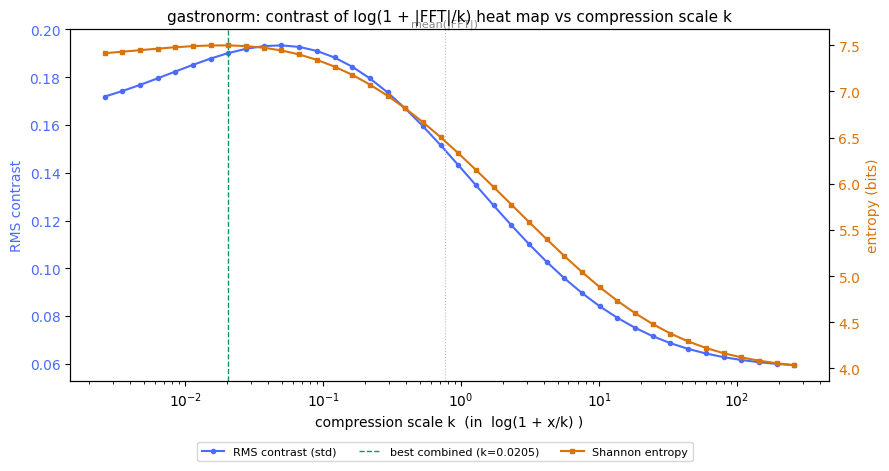

In [5]:
by_k = scores.sort_values("k")

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(by_k["k"], by_k["rms_contrast"], "o-", color="#4b6bfb", label="RMS contrast (std)", ms=3)
ax1.set_xscale("log")
ax1.set_xlabel("compression scale k  (in  log(1 + x/k) )")
ax1.set_ylabel("RMS contrast", color="#4b6bfb")
ax1.tick_params(axis="y", labelcolor="#4b6bfb")

ax2 = ax1.twinx()
ax2.plot(by_k["k"], by_k["entropy_bits"], "s-", color="#d9730d", label="Shannon entropy", ms=3)
ax2.set_ylabel("entropy (bits)", color="#d9730d")
ax2.tick_params(axis="y", labelcolor="#d9730d")

ax1.axvline(best["k"], color="#0f9660", ls="--", lw=1, label=f"best combined (k={best['k']:.3g})")
ax1.axvline(mag.mean(), color="#bbb", ls=":", lw=0.8)
ax1.text(mag.mean(), ax1.get_ylim()[1], "mean(|FFT|)", fontsize=8, ha="center", va="bottom", color="#888")

ax1.set_title(f"{DATASET}: contrast of log(1 + |FFT|/k) heat map vs compression scale k", fontsize=11)
fig.legend(loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=8)
fig.tight_layout()
plt.show()

# 5 Heat maps at representative compression scales

Lasers (100) on the y-axis, frequency on the x-axis. We show the raw (linear)
magnitude, log with `k = mag.max()` (mild compression), `k = mag.mean()`, the
best-scoring `k` found above, and a very small `k` (aggressive compression).

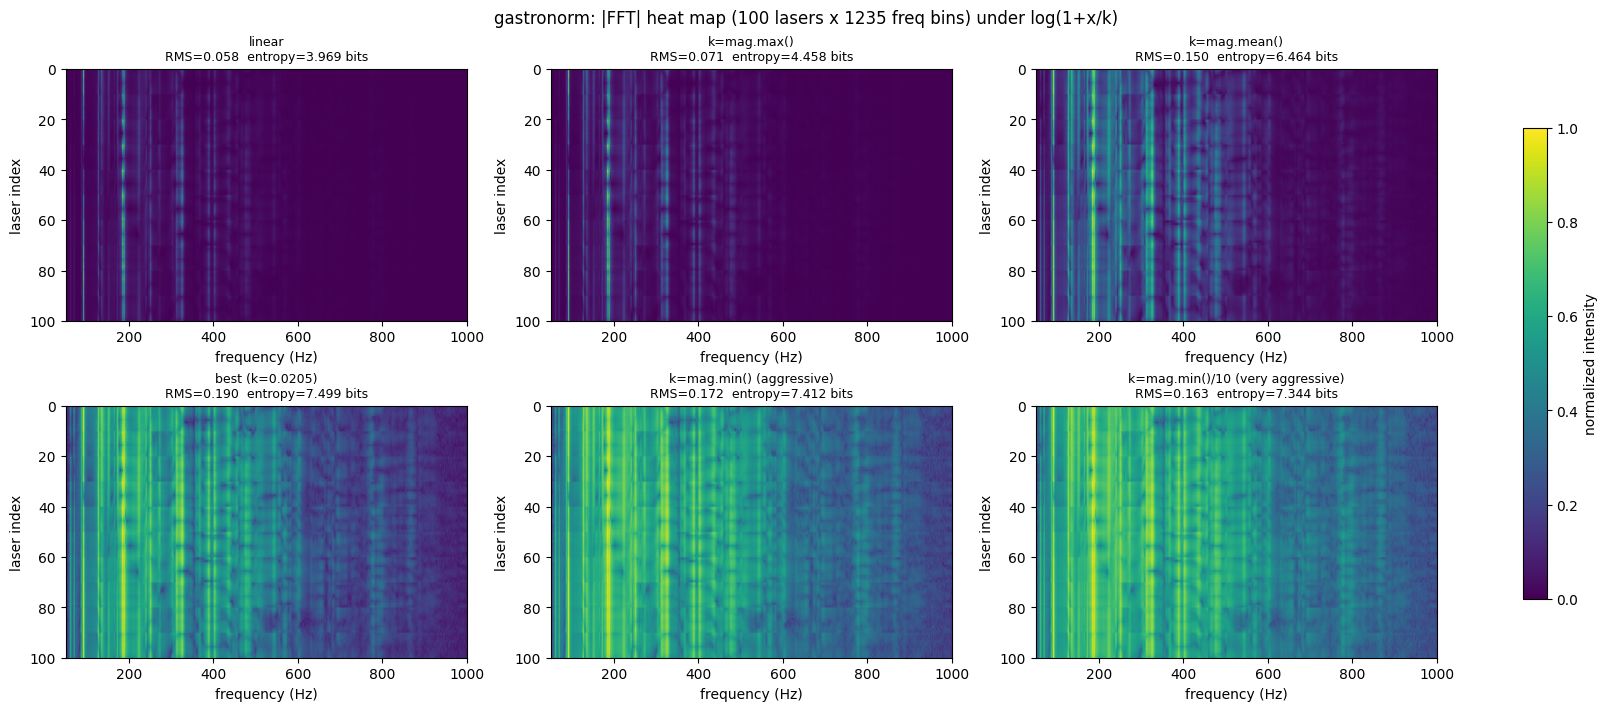

In [6]:
show_ks = [("linear", None), ("k=mag.max()", float(mag.max())), ("k=mag.mean()", float(mag.mean())),
           (f"best (k={best['k']:.3g})", float(best["k"])),
           ("k=mag.min() (aggressive)", float(mag.min())),
           ("k=mag.min()/10 (very aggressive)", float(mag.min()) / 10)]

fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
extent = [freqs[0], freqs[-1], mag.shape[0], 0]

for ax, (label, k) in zip(axes.flat, show_ks):
    img = normalize01(mag) if k is None else log_transform(mag, k)
    c_rms = rms_contrast(img)
    c_ent = shannon_entropy(img)
    im = ax.imshow(img, aspect="auto", extent=extent, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"{label}\nRMS={c_rms:.3f}  entropy={c_ent:.3f} bits", fontsize=9)
    ax.set_xlabel("frequency (Hz)")
    ax.set_ylabel("laser index")

fig.colorbar(im, ax=axes, shrink=0.8, label="normalized intensity")
fig.suptitle(f"{DATASET}: |FFT| heat map (100 lasers x {mag.shape[1]} freq bins) under log(1+x/k)", fontsize=12)
plt.show()

# 6 Best k across the whole dataset

The single-sample `k` above could just be an artifact of that one capture. Here we
load **every** sample's FFT in `DATASET`, compute each one's own `mag` (lasers x
freq, averaged over x/y), sweep the same `K_VALUES` grid per sample, and average the
two contrast scores across samples at each `k`. The per-sample `k`'s own natural
scale differs (different mean/max magnitude), so this also tells us whether a single
global `k` generalizes or whether a data-dependent choice (e.g. `k = mean(|FFT|)`)
would do better.

In [7]:
import time


def find_all_fft_paths(samples_dir: Path) -> list[Path]:
    paths = []
    for sample_dir in sorted(p for p in samples_dir.glob("*") if p.is_dir()):
        for name in FFT_NAMES:
            p = sample_dir / name
            if p.exists():
                paths.append(p)
                break
    return paths


all_fft_paths = find_all_fft_paths(SAMPLES_DIR)
print(f"{len(all_fft_paths)} samples with an FFT file in {DATASET}")

t0 = time.time()
all_mags = []
for p in all_fft_paths:
    with np.load(p) as z:
        all_mags.append(np.abs(z["fft"][0]).mean(axis=-1).astype(np.float32))   # (L, F)
print(f"loaded {len(all_mags)} samples in {time.time() - t0:.1f}s")

global_max = max(m.max() for m in all_mags)
global_min = min(m.min() for m in all_mags)
print(f"magnitude range across dataset: [{global_min:.4g}, {global_max:.4g}]")

3007 samples with an FFT file in gastronorm


loaded 3007 samples in 4.9s
magnitude range across dataset: [8.397e-05, 54.67]


In [8]:
t0 = time.time()
per_sample_rows = []
for si, m in enumerate(all_mags):
    for k in K_VALUES:
        img = log_transform(m, k)
        per_sample_rows.append((si, k, rms_contrast(img), shannon_entropy(img)))
print(f"scored {len(all_mags)} samples x {len(K_VALUES)} k-values in {time.time() - t0:.1f}s")

per_sample = pd.DataFrame(per_sample_rows, columns=["sample_idx", "k", "rms_contrast", "entropy_bits"])

dataset_scores = (per_sample.groupby("k")
                   .agg(rms_contrast_mean=("rms_contrast", "mean"),
                        rms_contrast_std=("rms_contrast", "std"),
                        entropy_mean=("entropy_bits", "mean"),
                        entropy_std=("entropy_bits", "std"))
                   .reset_index().sort_values("k").reset_index(drop=True))
dataset_scores["rms_rank"] = dataset_scores["rms_contrast_mean"].rank(ascending=False)
dataset_scores["entropy_rank"] = dataset_scores["entropy_mean"].rank(ascending=False)
dataset_scores["combined_rank_score"] = dataset_scores["rms_rank"] * dataset_scores["entropy_rank"]
dataset_scores = dataset_scores.sort_values("combined_rank_score").reset_index(drop=True)

dataset_best = dataset_scores.iloc[0]
print(f"\nbest compression scale over all {len(all_mags)} samples: k={dataset_best['k']:.4g}  "
      f"(mean rms={dataset_best['rms_contrast_mean']:.4f} +/- {dataset_best['rms_contrast_std']:.4f}, "
      f"mean entropy={dataset_best['entropy_mean']:.4f} +/- {dataset_best['entropy_std']:.4f} bits)")
dataset_scores.head(10)

scored 3007 samples x 40 k-values in 65.2s

best compression scale over all 3007 samples: k=0.01138  (mean rms=0.1721 +/- 0.0119, mean entropy=7.3554 +/- 0.1043 bits)


,k,rms_contrast_mean,rms_contrast_std,entropy_mean,entropy_std,rms_rank,entropy_rank,combined_rank_score
0,0.011379,0.172141,0.011872,7.355401,0.104343,6.0,1.0,6.0
1,0.027589,0.175969,0.013631,7.314774,0.127999,1.0,7.0,7.0
2,0.015287,0.174037,0.012361,7.352302,0.110217,5.0,2.0,10.0
3,0.020537,0.175368,0.012946,7.339438,0.118039,3.0,5.0,15.0
4,0.037063,0.175695,0.014412,7.276464,0.140195,2.0,10.0,20.0
5,0.008471,0.169851,0.011472,7.350837,0.100147,8.0,3.0,24.0
6,0.006305,0.167331,0.011153,7.340641,0.097348,10.0,4.0,40.0
7,0.049791,0.174433,0.015279,7.222945,0.154560,4.0,11.0,44.0
8,0.004694,0.164732,0.010910,7.326716,0.095687,11.0,6.0,66.0
9,0.066889,0.172113,0.016208,7.153086,0.170883,7.0,12.0,84.0


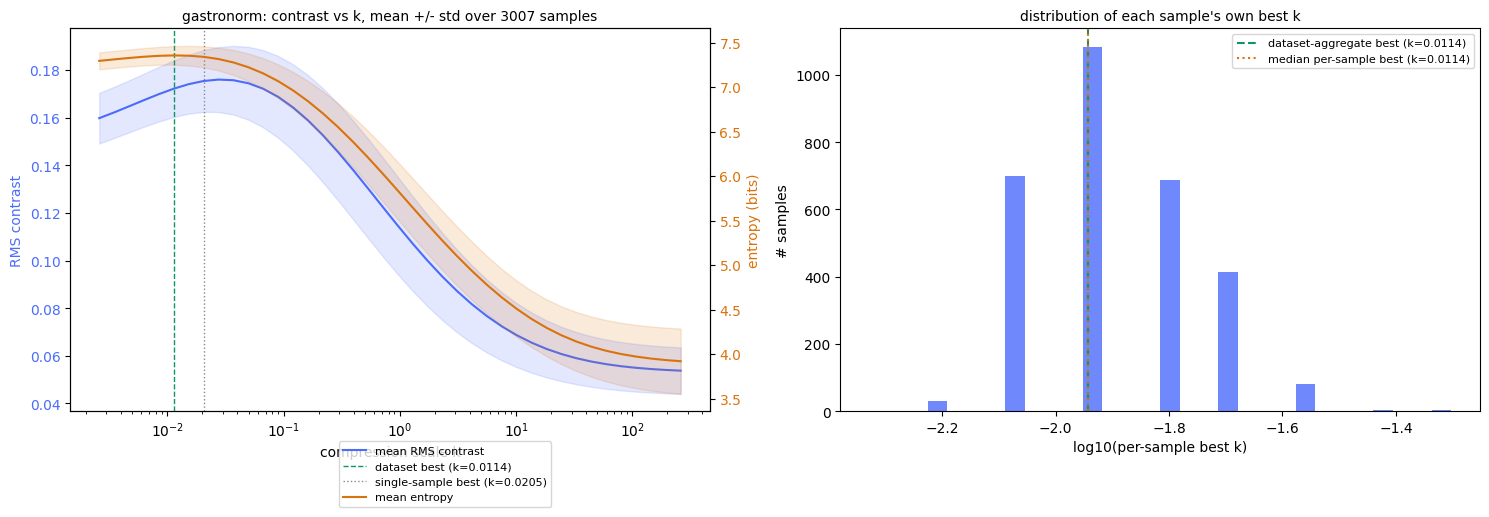

per-sample best k: median=0.01138, mean=0.01334, std=0.004897


In [9]:
by_k_ds = dataset_scores.sort_values("k").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

ax1 = axes[0]
ax1.plot(by_k_ds["k"], by_k_ds["rms_contrast_mean"], "-", color="#4b6bfb", label="mean RMS contrast")
ax1.fill_between(by_k_ds["k"],
                  by_k_ds["rms_contrast_mean"] - by_k_ds["rms_contrast_std"],
                  by_k_ds["rms_contrast_mean"] + by_k_ds["rms_contrast_std"],
                  color="#4b6bfb", alpha=0.15)
ax1.set_xscale("log")
ax1.set_xlabel("compression scale k")
ax1.set_ylabel("RMS contrast", color="#4b6bfb")
ax1.tick_params(axis="y", labelcolor="#4b6bfb")

ax1b = ax1.twinx()
ax1b.plot(by_k_ds["k"], by_k_ds["entropy_mean"], "-", color="#d9730d", label="mean entropy")
ax1b.fill_between(by_k_ds["k"],
                   by_k_ds["entropy_mean"] - by_k_ds["entropy_std"],
                   by_k_ds["entropy_mean"] + by_k_ds["entropy_std"],
                   color="#d9730d", alpha=0.15)
ax1b.set_ylabel("entropy (bits)", color="#d9730d")
ax1b.tick_params(axis="y", labelcolor="#d9730d")
ax1.axvline(dataset_best["k"], color="#0f9660", ls="--", lw=1,
            label=f"dataset best (k={dataset_best['k']:.3g})")
ax1.axvline(best["k"], color="#888", ls=":", lw=1, label=f"single-sample best (k={best['k']:.3g})")
ax1.set_title(f"{DATASET}: contrast vs k, mean +/- std over {len(all_mags)} samples", fontsize=10)
fig.legend(loc="lower center", bbox_to_anchor=(0.3, -0.08), ncol=1, fontsize=8)

# per-sample best-k distribution
best_k_per_sample = (per_sample
                      .assign(rms_rank=lambda d: d.groupby("sample_idx")["rms_contrast"].rank(ascending=False),
                              ent_rank=lambda d: d.groupby("sample_idx")["entropy_bits"].rank(ascending=False))
                      .assign(combo=lambda d: d["rms_rank"] * d["ent_rank"])
                      .sort_values(["sample_idx", "combo"])
                      .groupby("sample_idx").first()["k"])

ax2 = axes[1]
ax2.hist(np.log10(best_k_per_sample), bins=30, color="#4b6bfb", alpha=0.8)
ax2.axvline(np.log10(dataset_best["k"]), color="#0f9660", ls="--", lw=1.5,
            label=f"dataset-aggregate best (k={dataset_best['k']:.3g})")
ax2.axvline(np.log10(best_k_per_sample.median()), color="#d9730d", ls=":", lw=1.5,
            label=f"median per-sample best (k={best_k_per_sample.median():.3g})")
ax2.set_xlabel("log10(per-sample best k)")
ax2.set_ylabel("# samples")
ax2.set_title("distribution of each sample's own best k", fontsize=10)
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

print(f"per-sample best k: median={best_k_per_sample.median():.4g}, "
      f"mean={best_k_per_sample.mean():.4g}, std={best_k_per_sample.std():.4g}")

# 7 A more direct contrast metric: RMS contrast alone

Entropy (section 2) is a proxy for *dynamic-range utilization*, not contrast itself —
it's borrowed from histogram-equalization theory. The metric image-processing
actually calls "contrast" for general images is **RMS contrast** (Peli, 1990):
`std(I) / mean(I)` for a normalized image, or simply `std(I)` once `I` is already
scaled to `[0, 1]` (our case, so the two coincide up to the constant `mean(I)`).
Other classic definitions — Michelson contrast `(max-min)/(max+min)` and Weber
contrast `(I-I_bg)/I_bg` — only use the image extremes or a background level, which
suits gratings or a single-object-on-background scene, not a heat map with structure
everywhere. RMS contrast uses every pixel, which is why it's the standard choice for
images like ours. We already computed it — this section isolates it as the primary
number, with entropy demoted to a secondary sanity check.

# 8 Empirical check: 5 samples x several k values

Pick 5 samples spread across the dataset and render each at: linear (no log), a mild
compression (`k=mag.max()`), the dataset-optimal `k` found in section 6, an aggressive
compression (`k=mag.min()`), and a too-aggressive one (`k=mag.min()/50`) — so we can
see contrast rise then collapse by eye, not just in the numbers.

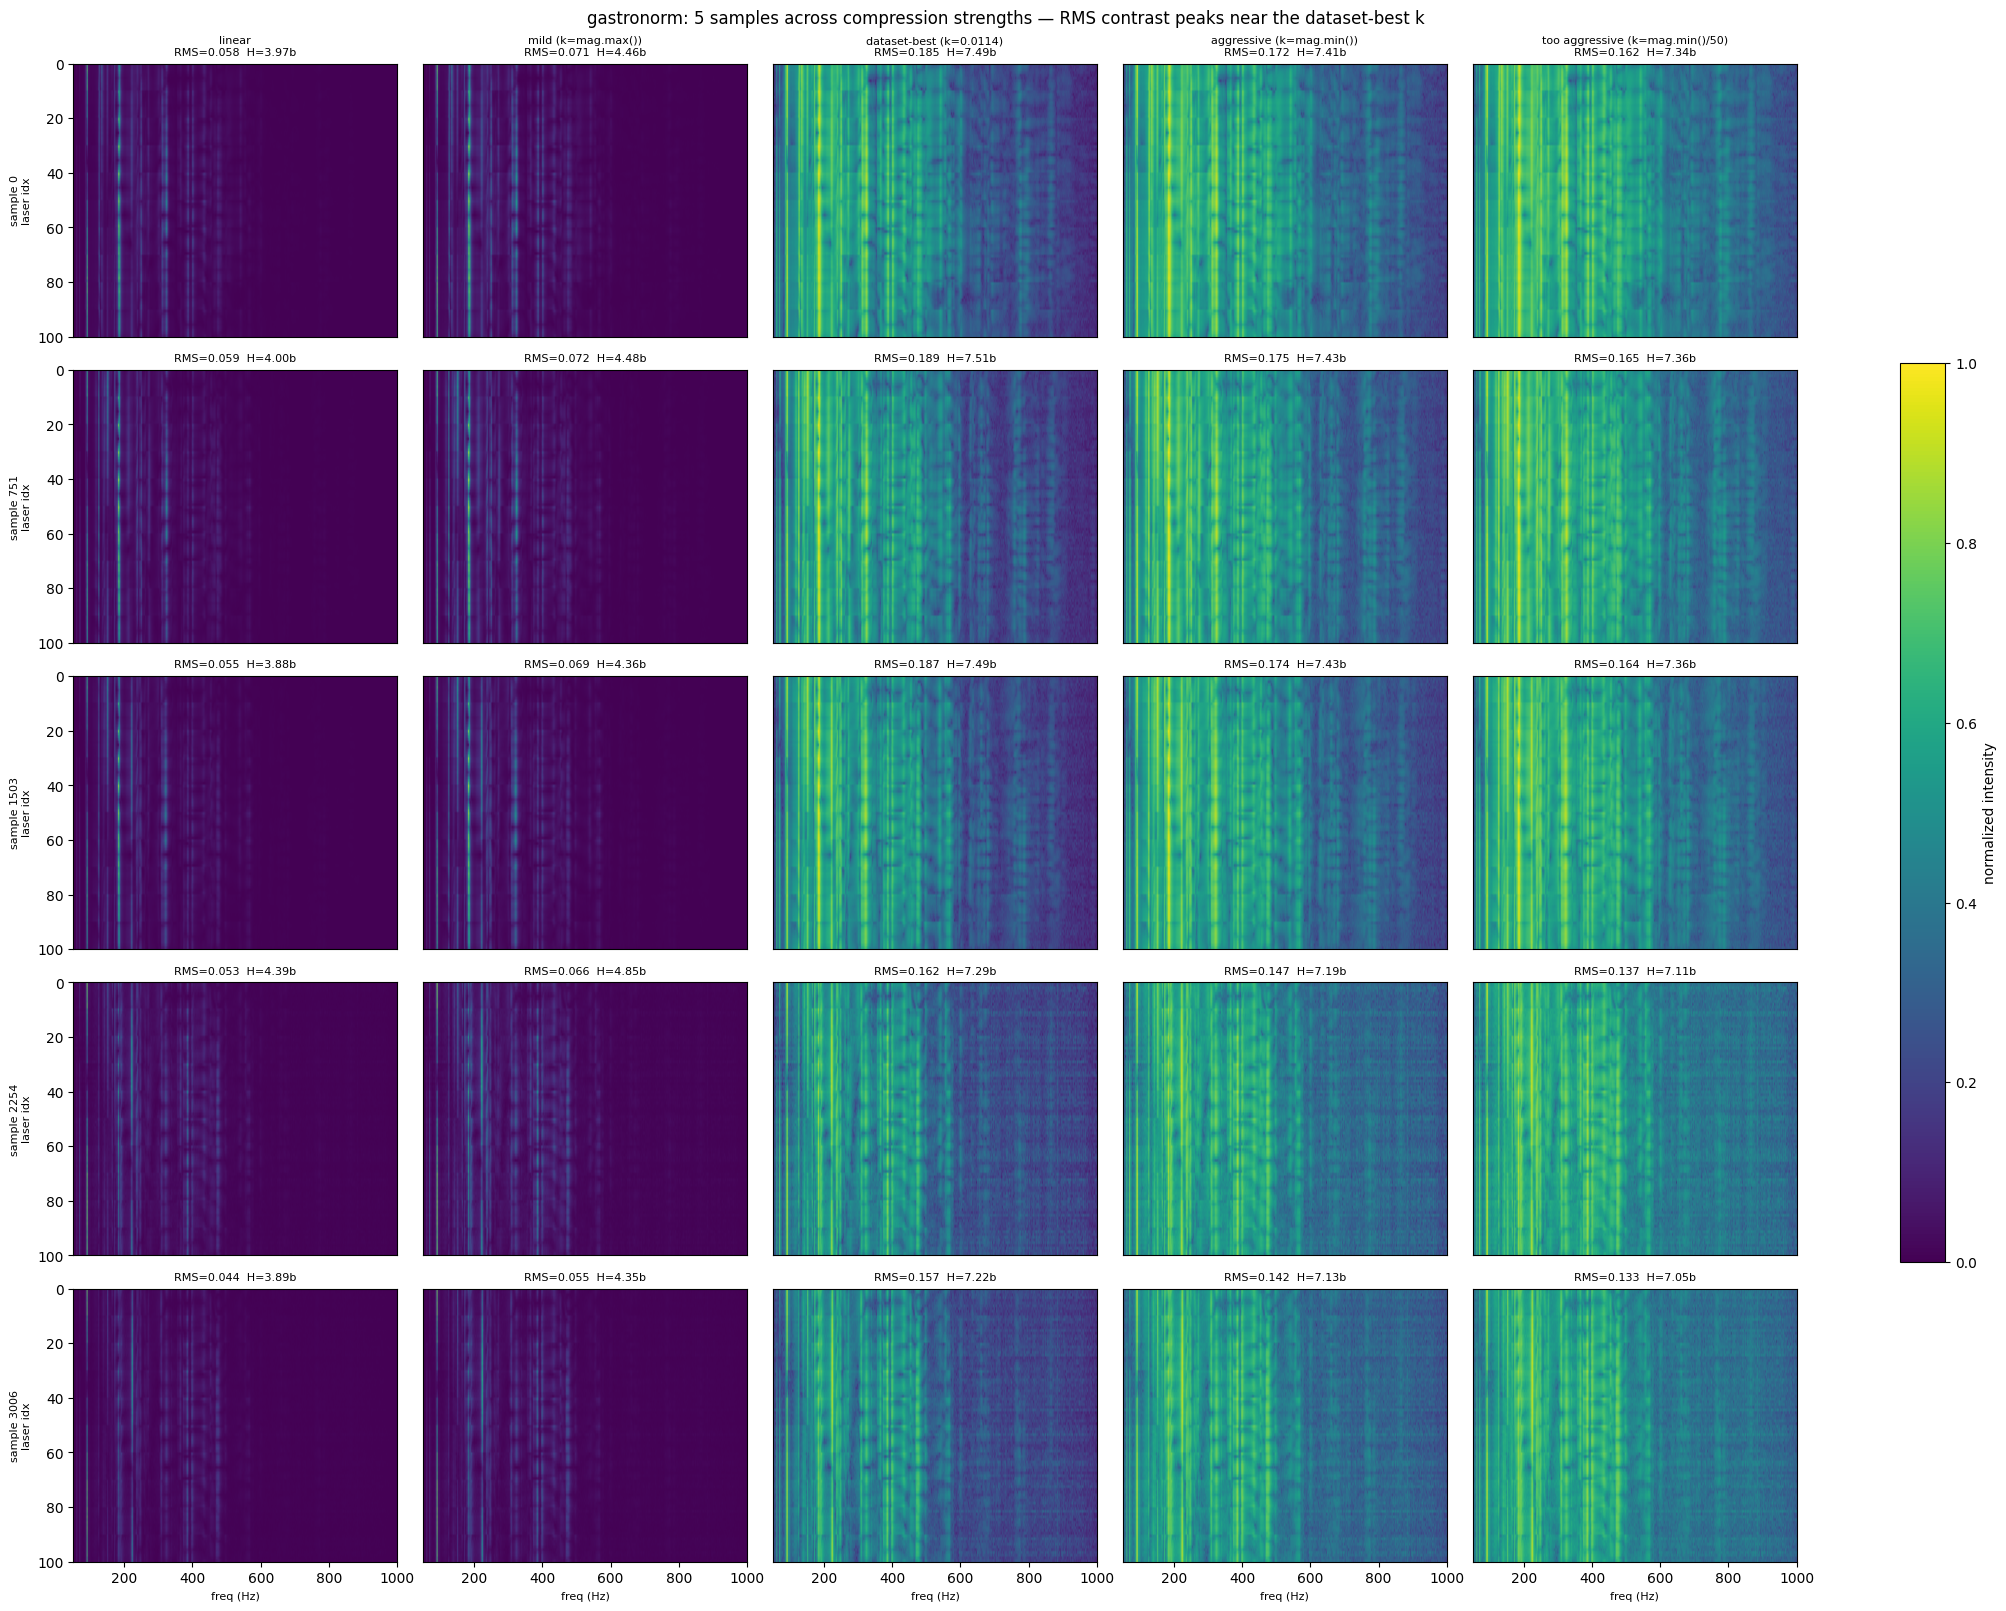

In [10]:
n_show = 5
sample_idxs = np.linspace(0, len(all_mags) - 1, n_show).astype(int)

k_cols = [
    ("linear", None),
    ("mild (k=mag.max())", lambda m: float(m.max())),
    (f"dataset-best (k={dataset_best['k']:.3g})", lambda m: float(dataset_best["k"])),
    ("aggressive (k=mag.min())", lambda m: float(m.min())),
    ("too aggressive (k=mag.min()/50)", lambda m: float(m.min()) / 50),
]

fig, axes = plt.subplots(n_show, len(k_cols), figsize=(4 * len(k_cols), 3.2 * n_show), constrained_layout=True)
extent = [freqs[0], freqs[-1], mag.shape[0], 0]

for row, si in enumerate(sample_idxs):
    m = all_mags[si]
    for col, (label, kf) in enumerate(k_cols):
        ax = axes[row, col]
        img = normalize01(m) if kf is None else log_transform(m, kf(m))
        c_rms, c_ent = rms_contrast(img), shannon_entropy(img)
        im = ax.imshow(img, aspect="auto", extent=extent, cmap="viridis", vmin=0, vmax=1)
        ax.set_title(f"RMS={c_rms:.3f}  H={c_ent:.2f}b", fontsize=8)
        if row == 0:
            ax.set_title(f"{label}\nRMS={c_rms:.3f}  H={c_ent:.2f}b", fontsize=8)
        if col == 0:
            ax.set_ylabel(f"sample {si}\nlaser idx", fontsize=8)
        else:
            ax.set_yticks([])
        if row == n_show - 1:
            ax.set_xlabel("freq (Hz)", fontsize=8)
        else:
            ax.set_xticks([])

fig.colorbar(im, ax=axes, shrink=0.6, label="normalized intensity")
fig.suptitle(f"{DATASET}: {n_show} samples across compression strengths — RMS contrast peaks near the dataset-best k", fontsize=12)
plt.show()

# 9 Grating-style contrast: per-frequency-band Michelson contrast

The heat map isn't a clean two-level grating overall (it has continuous structure,
not just bright/dark bars), so classic whole-image Michelson contrast
`(I_max - I_min)/(I_max + I_min)` would collapse everything down to just 2 of the
~123,500 pixels — extremely sensitive to a single noisy outlier laser or the noise
floor. But **within each frequency bin**, the 100 lasers *do* look like a grating:
some lasers sit on a resonance peak, others don't, and we want to know how well those
peaks stand out from the troughs *at that frequency*, independent of how loud that
frequency band is overall.

So we compute Michelson contrast **per frequency column** (across the 100 lasers),
then average over columns:

`M = mean_f[ (max_laser(I[:,f]) - min_laser(I[:,f])) / (max_laser(I[:,f]) + min_laser(I[:,f]) + eps) ]`

This answers a different question than RMS contrast: not "how spread out are all
pixel values overall" but "at a given frequency, how sharply does the laser pattern
stand out from its own local floor" — the grating-resolution question.

single-sample best k by RMS/entropy combo: 0.02054
single-sample best k by Michelson contrast: 260.1  (michelson=0.7809)


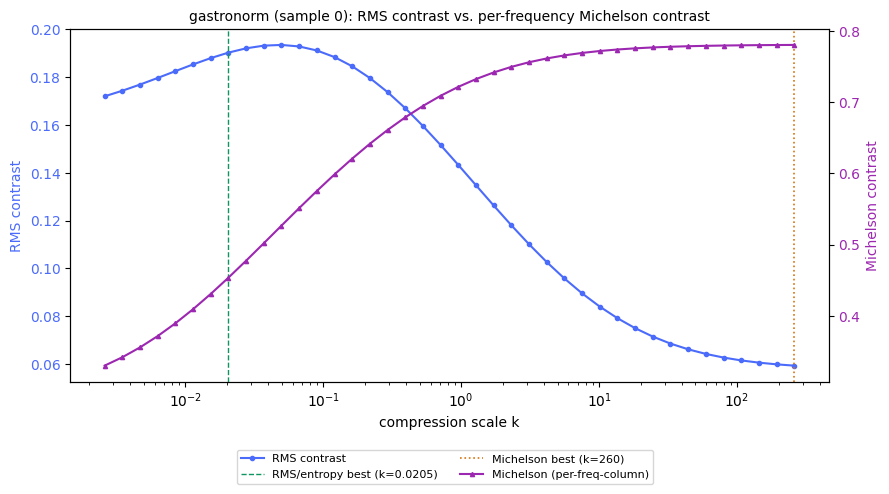

In [11]:
def michelson_contrast(img01: np.ndarray, axis: int = 0, eps: float = 1e-8) -> float:
    """Per-column Michelson contrast (max-min)/(max+min) across `axis`, averaged over
    the other axis. axis=0 -> contrast across lasers, within each frequency column."""
    lo = img01.min(axis=axis)
    hi = img01.max(axis=axis)
    return float(np.mean((hi - lo) / (hi + lo + eps)))


# re-score the single sample's sweep with Michelson contrast added
rows = []
for k in K_VALUES:
    img = log_transform(mag, k)
    rows.append(dict(
        k=k,
        rms_contrast=rms_contrast(img),
        entropy_bits=shannon_entropy(img),
        michelson=michelson_contrast(img),
    ))
scores_mich = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)

best_michelson = scores_mich.loc[scores_mich["michelson"].idxmax()]
print(f"single-sample best k by RMS/entropy combo: {best['k']:.4g}")
print(f"single-sample best k by Michelson contrast: {best_michelson['k']:.4g}  "
      f"(michelson={best_michelson['michelson']:.4f})")

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(scores_mich["k"], scores_mich["rms_contrast"], "o-", ms=3, color="#4b6bfb", label="RMS contrast")
ax1.set_xscale("log")
ax1.set_xlabel("compression scale k")
ax1.set_ylabel("RMS contrast", color="#4b6bfb")
ax1.tick_params(axis="y", labelcolor="#4b6bfb")

ax2 = ax1.twinx()
ax2.plot(scores_mich["k"], scores_mich["michelson"], "^-", ms=3, color="#9c27b0", label="Michelson (per-freq-column)")
ax2.set_ylabel("Michelson contrast", color="#9c27b0")
ax2.tick_params(axis="y", labelcolor="#9c27b0")

ax1.axvline(best["k"], color="#0f9660", ls="--", lw=1, label=f"RMS/entropy best (k={best['k']:.3g})")
ax1.axvline(best_michelson["k"], color="#d9730d", ls=":", lw=1.2, label=f"Michelson best (k={best_michelson['k']:.3g})")
ax1.set_title(f"{DATASET} (sample 0): RMS contrast vs. per-frequency Michelson contrast", fontsize=10)
fig.legend(loc="lower center", bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

### Reading this: Michelson disagrees with RMS/entropy, and it's a known failure mode

Michelson contrast climbs monotonically and picks `k ≈ 260` — essentially the *least*
compression in the whole sweep, the opposite of RMS/entropy's `k ≈ 0.02`. This isn't
a real signal; it's Michelson contrast being fooled by near-zero minimums:

```
at k=260: 81% of frequency columns have their weakest laser normalized to < 0.01
          median column min = 0.002, median column max = 0.023
          whole-image mean = 0.03  (i.e. the image is almost entirely dark)
```

`(hi - lo) / (hi + lo)` -> `hi / hi` = 1 whenever `lo` is near zero, *regardless of
how small hi itself is*. At large `k`, most laser columns have one laser sitting
right at the (unused) bottom of the global normalization range, so Michelson reports
near-maximal "contrast" for a column that is, in absolute terms, barely above noise —
exactly the almost-black `linear` / `mild` panels in section 8's image grid that we
could see by eye were low-contrast. This is the textbook limitation of Michelson
contrast: it's built for two dominant, comparably-sized levels (a real grating's peak
and trough), and degenerates when one side of the ratio approaches zero. RMS contrast
and entropy, which weigh the *whole* distribution rather than just the local min/max,
don't have this failure mode — which is why they agree with each other and with the
visual grid, while Michelson here does not. We keep the metric defined above for
reference, but do not use it to pick `k`.

# 10 Empirical check: Michelson contrast across samples and k

Same 5 samples and same panel layout as section 8, now with Michelson contrast (`M`)
printed alongside RMS (`R`) and entropy (`H`) in every panel. Watch the `too
aggressive` and `linear` columns in particular — those are the visually darkest,
lowest-contrast panels, yet `M` should be highest there, making the degenerate
near-zero-minimum failure mode visible directly on the image rather than only in the
line plot above.

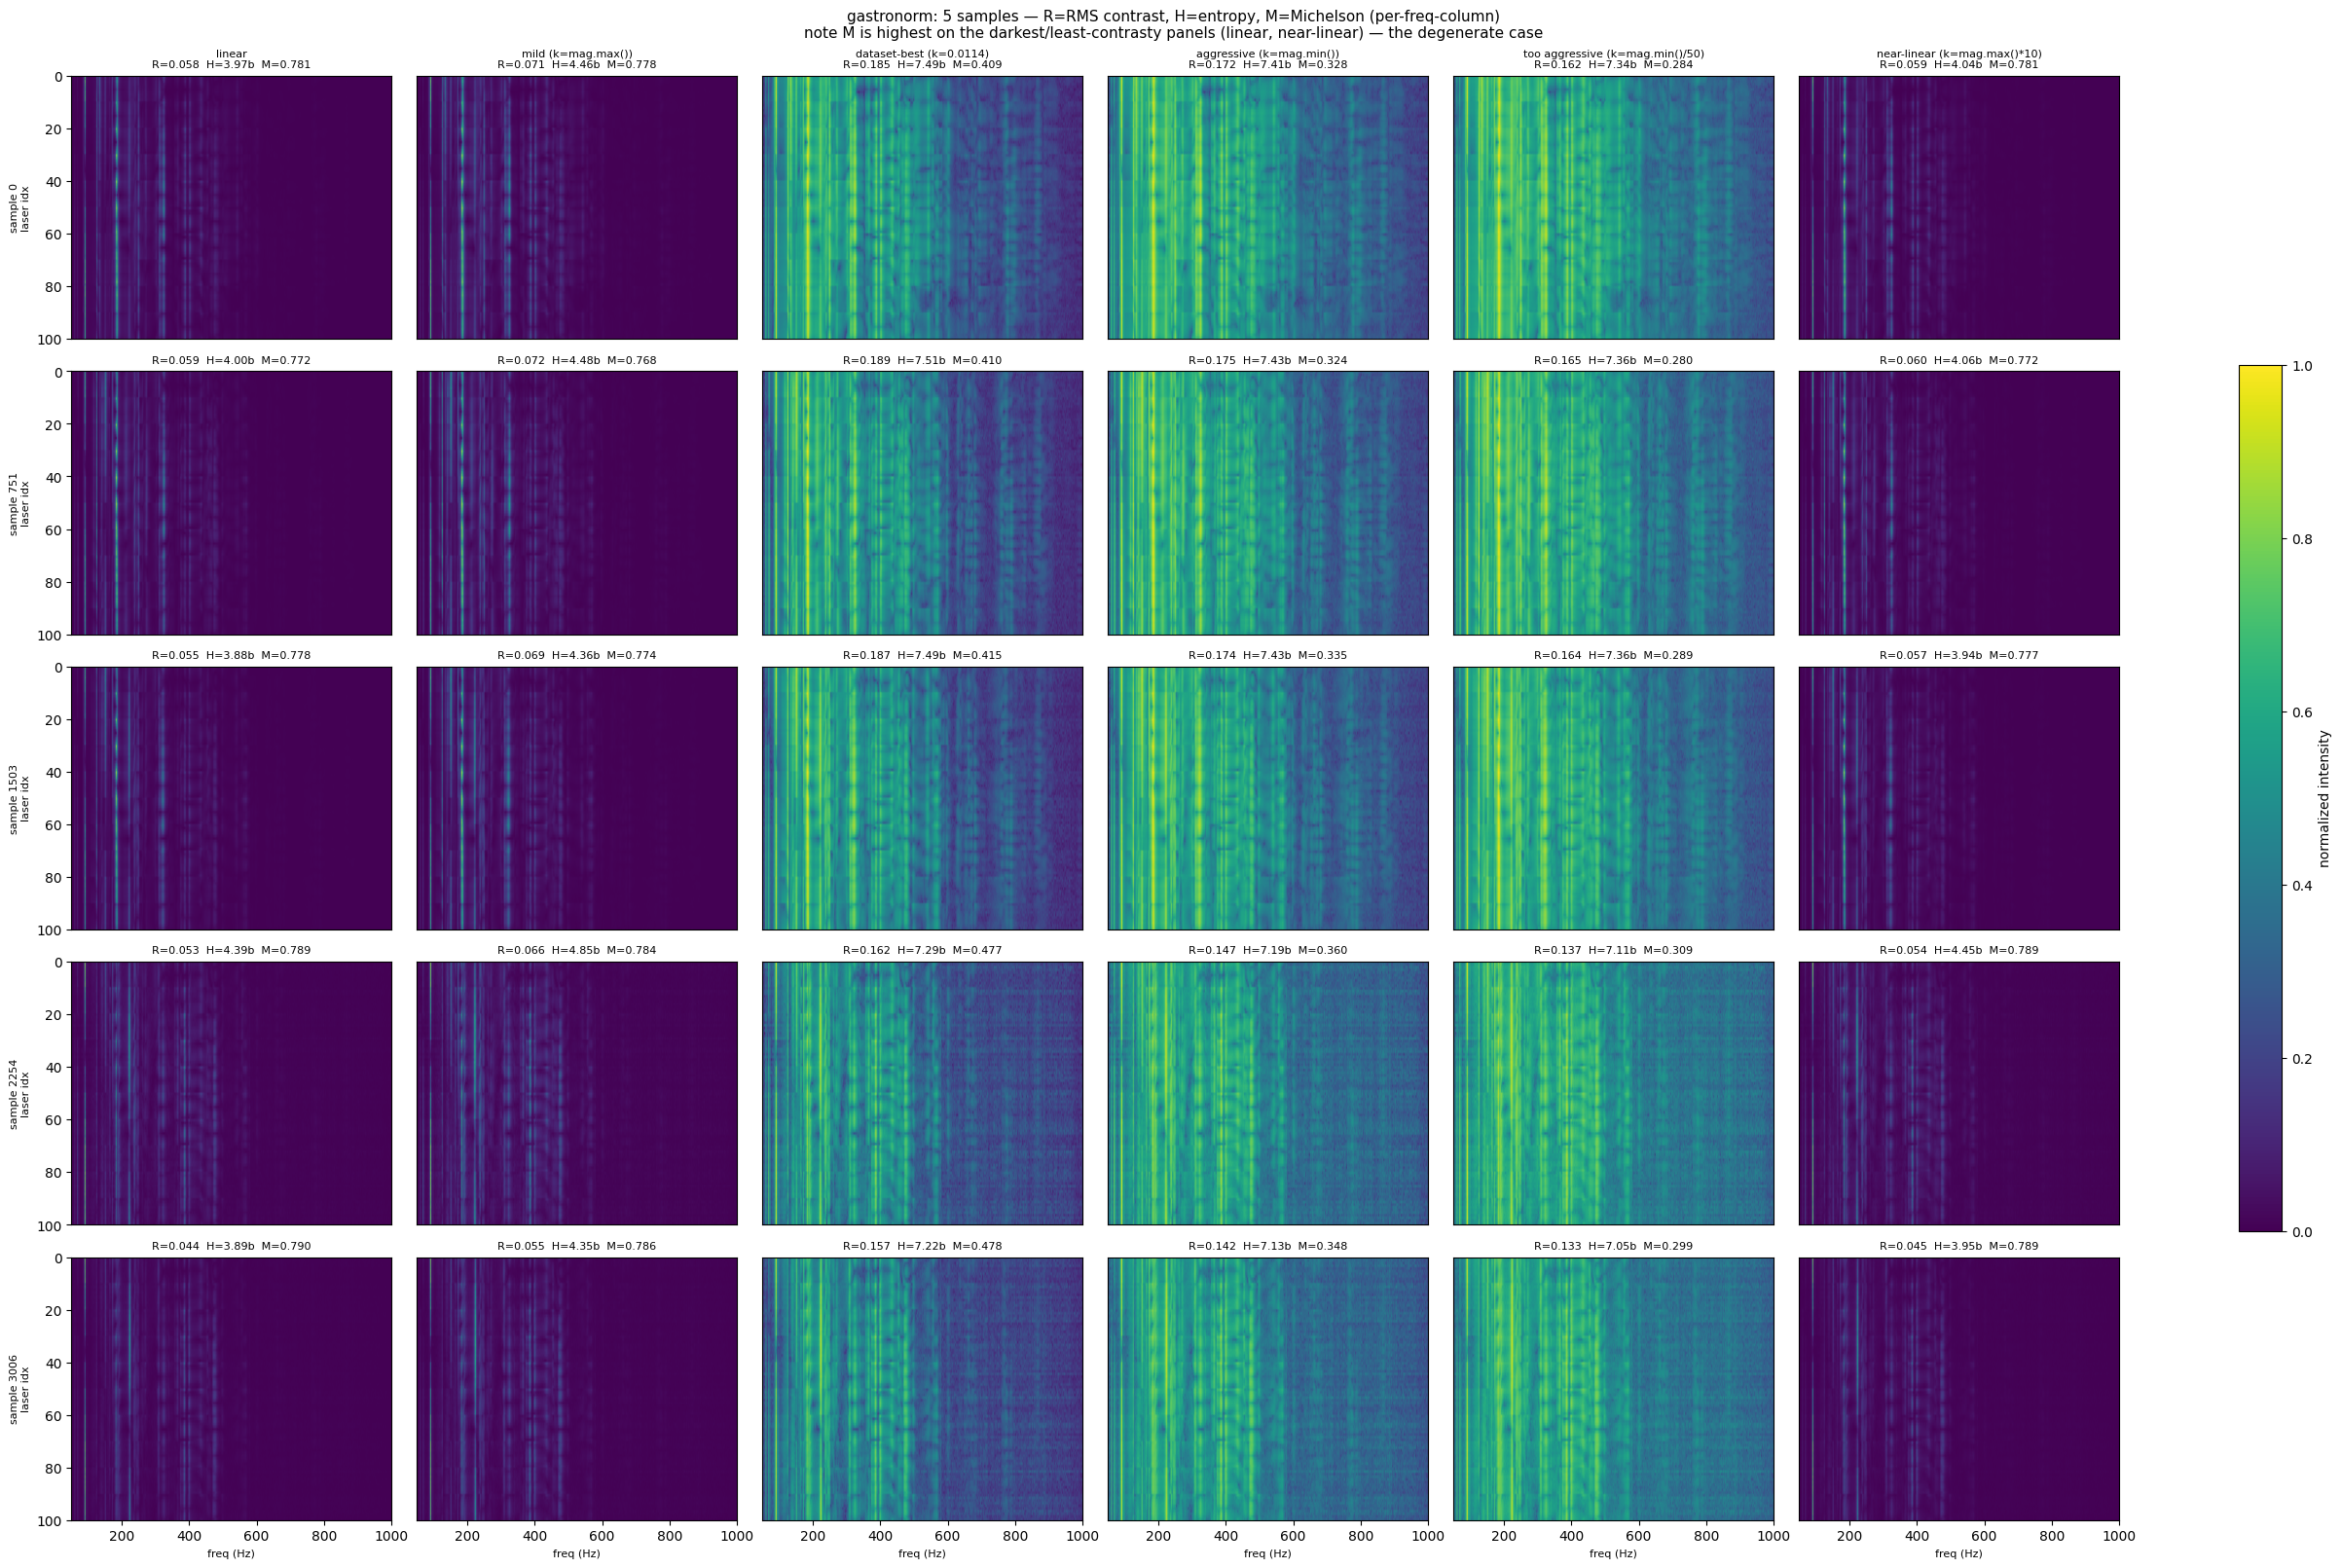

In [12]:
# extend the k range so "too aggressive" and a near-linear extreme both appear,
# matching section 8's columns but adding one very-large-k column for Michelson
k_cols_mich = [
    ("linear", None),
    ("mild (k=mag.max())", lambda m: float(m.max())),
    (f"dataset-best (k={dataset_best['k']:.3g})", lambda m: float(dataset_best["k"])),
    ("aggressive (k=mag.min())", lambda m: float(m.min())),
    ("too aggressive (k=mag.min()/50)", lambda m: float(m.min()) / 50),
    ("near-linear (k=mag.max()*10)", lambda m: float(m.max()) * 10),
]

fig, axes = plt.subplots(n_show, len(k_cols_mich), figsize=(4 * len(k_cols_mich), 3.2 * n_show), constrained_layout=True)
extent = [freqs[0], freqs[-1], mag.shape[0], 0]

for row, si in enumerate(sample_idxs):
    m = all_mags[si]
    for col, (label, kf) in enumerate(k_cols_mich):
        ax = axes[row, col]
        img = normalize01(m) if kf is None else log_transform(m, kf(m))
        c_rms, c_ent, c_mich = rms_contrast(img), shannon_entropy(img), michelson_contrast(img)
        im = ax.imshow(img, aspect="auto", extent=extent, cmap="viridis", vmin=0, vmax=1)
        title = f"R={c_rms:.3f}  H={c_ent:.2f}b  M={c_mich:.3f}"
        ax.set_title(f"{label}\n{title}" if row == 0 else title, fontsize=8)
        if col == 0:
            ax.set_ylabel(f"sample {si}\nlaser idx", fontsize=8)
        else:
            ax.set_yticks([])
        if row == n_show - 1:
            ax.set_xlabel("freq (Hz)", fontsize=8)
        else:
            ax.set_xticks([])

fig.colorbar(im, ax=axes, shrink=0.6, label="normalized intensity")
fig.suptitle(f"{DATASET}: {n_show} samples — R=RMS contrast, H=entropy, M=Michelson (per-freq-column)\n"
             "note M is highest on the darkest/least-contrasty panels (linear, near-linear) — the degenerate case", fontsize=11)
plt.show()